<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Before-your-start:" data-toc-modified-id="Before-your-start:-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Before your start:</a></span></li><li><span><a href="#Challenge-1---Import-and-Describe-the-Dataset" data-toc-modified-id="Challenge-1---Import-and-Describe-the-Dataset-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Challenge 1 - Import and Describe the Dataset</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Explore-the-dataset-with-mathematical-and-visualization-techniques.-What-do-you-find?" data-toc-modified-id="Explore-the-dataset-with-mathematical-and-visualization-techniques.-What-do-you-find?-2.0.0.1"><span class="toc-item-num">2.0.0.1&nbsp;&nbsp;</span>Explore the dataset with mathematical and visualization techniques. What do you find?</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#Challenge-2---Data-Cleaning-and-Transformation" data-toc-modified-id="Challenge-2---Data-Cleaning-and-Transformation-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Challenge 2 - Data Cleaning and Transformation</a></span></li><li><span><a href="#Challenge-3---Data-Preprocessing" data-toc-modified-id="Challenge-3---Data-Preprocessing-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Challenge 3 - Data Preprocessing</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#We-will-use-the-StandardScaler-from-sklearn.preprocessing-and-scale-our-data.-Read-more-about-StandardScaler-here." data-toc-modified-id="We-will-use-the-StandardScaler-from-sklearn.preprocessing-and-scale-our-data.-Read-more-about-StandardScaler-here.-4.0.0.1"><span class="toc-item-num">4.0.0.1&nbsp;&nbsp;</span>We will use the <code>StandardScaler</code> from <code>sklearn.preprocessing</code> and scale our data. Read more about <code>StandardScaler</code> <a href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler" target="_blank">here</a>.</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#Challenge-4---Data-Clustering-with-K-Means" data-toc-modified-id="Challenge-4---Data-Clustering-with-K-Means-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Challenge 4 - Data Clustering with K-Means</a></span></li><li><span><a href="#Challenge-5---Data-Clustering-with-DBSCAN" data-toc-modified-id="Challenge-5---Data-Clustering-with-DBSCAN-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Challenge 5 - Data Clustering with DBSCAN</a></span></li><li><span><a href="#Challenge-6---Compare-K-Means-with-DBSCAN" data-toc-modified-id="Challenge-6---Compare-K-Means-with-DBSCAN-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Challenge 6 - Compare K-Means with DBSCAN</a></span></li><li><span><a href="#Bonus-Challenge-2---Changing-K-Means-Number-of-Clusters" data-toc-modified-id="Bonus-Challenge-2---Changing-K-Means-Number-of-Clusters-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Bonus Challenge 2 - Changing K-Means Number of Clusters</a></span></li><li><span><a href="#Bonus-Challenge-3---Changing-DBSCAN-eps-and-min_samples" data-toc-modified-id="Bonus-Challenge-3---Changing-DBSCAN-eps-and-min_samples-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>Bonus Challenge 3 - Changing DBSCAN <code>eps</code> and <code>min_samples</code></a></span></li></ul></div>

# Before your start:
- Read the README.md file
- Comment as much as you can and use the resources in the README.md file
- Happy learning!

In [5]:
# Import your libraries:

#%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings                                              
from sklearn.exceptions import DataConversionWarning          
warnings.filterwarnings(action='ignore', category=DataConversionWarning)

# Challenge 1 - Import and Describe the Dataset

In this lab, we will use a dataset containing information about customer preferences. We will look at how much each customer spends in a year on each subcategory in the grocery store and try to find similarities using clustering.

The origin of the dataset is [here](https://archive.ics.uci.edu/ml/datasets/wholesale+customers).

In [8]:
# loading the data: Wholesale customers data
wholesale_customer = pd.read_csv('../data/Wholesale customers data.csv')

#### Explore the dataset with mathematical and visualization techniques. What do you find?

Checklist:

* What does each column mean?
* Any categorical data to convert?
* Any missing data to remove?
* Column collinearity - any high correlations?
* Descriptive statistics - any outliers to remove?
* Column-wise data distribution - is the distribution skewed?
* Etc.

Additional info: Over a century ago, an Italian economist named Vilfredo Pareto discovered that roughly 20% of the customers account for 80% of the typical retail sales. This is called the [Pareto principle](https://en.wikipedia.org/wiki/Pareto_principle). Check if this dataset displays this characteristic.

In [10]:
#display the wholesale data
wholesale_customer.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [11]:
#understanding the column and Categorial data
wholesale_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [12]:
#check for missing Data
wholesale_customer.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [13]:
# metrics like the mean, minimum, maximum, and percentiles for every column:
wholesale_customer.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


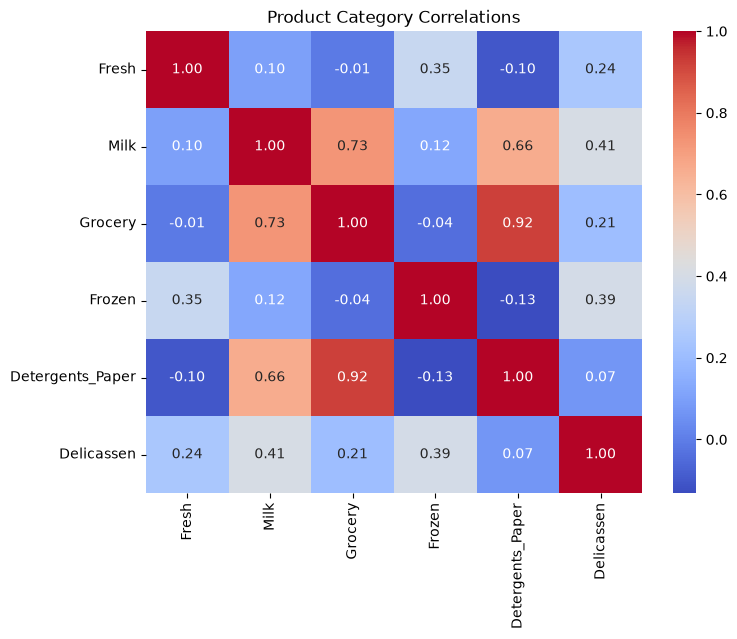

In [14]:
#lets check the co-relation between these columns
# Plot a correlation heatmap to look for highly related columns
plt.figure(figsize=(8, 6))
sns.heatmap(wholesale_customer.drop(columns=['Channel', 'Region']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Product Category Correlations")
plt.show()

In [16]:
#Testing the Pareto Principle (The 80/20 Rule) to see if 20% of your customers generate 80% of the sales.
 
# 1. Sum up all product categories for each customer to get their Total Spend
spending_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
wholesale_customer['Total_Spend'] = wholesale_customer[spending_cols].sum(axis=1)

# 2. Sort customers from highest spender to lowest spender
sorted_spend = wholesale_customer['Total_Spend'].sort_values(ascending=False).reset_index(drop=True)

# 3. Calculate 20% of the customer count
top_20_percent_count = int(len(sorted_spend) * 0.20)
total_revenue = sorted_spend.sum()

# 4. Calculate what percent of revenue the top 20% actually accounts for
revenue_from_top_20 = sorted_spend.iloc[:top_20_percent_count].sum()
percentage = (revenue_from_top_20 / total_revenue) * 100

print(f"The top 20% of customers account for {percentage:.2f}% of total sales.")


The top 20% of customers account for 42.90% of total sales.


### My Observation On this Data

The top 20% of customers account for 42.90% of total sales, showing that spending is more evenly distributed across the customer base rather than strictly following the 80/20 Pareto principle.

# Challenge 2 - Data Cleaning and Transformation

If your conclusion from the previous challenge is the data need cleaning/transformation, do it in the cells below. However, if your conclusion is the data need not be cleaned or transformed, feel free to skip this challenge. But if you do choose the latter, please provide rationale.

In [22]:
# Need Transformation
# Select the raw numerical columns
spending_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

# Apply log transformation to handle skewness and outliers
customers_log = np.log(wholesale_customer[spending_cols])
customers_log.head()




,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,9.446913,9.175335,8.930759,5.365976,7.891331,7.198931
1,8.861775,9.191158,9.166179,7.474205,8.099554,7.482119
2,8.756682,9.083416,8.946896,7.785305,8.165079,8.967504
3,9.492884,7.086738,8.347827,8.764678,6.228511,7.488853
4,10.026369,8.596004,8.881558,8.272571,7.482682,8.553525


**Your comment here**

-  Log transformation was applied to correct the severe right-skewness and minimize the impact of extreme outliers observed in the product categories.
- StandardScaler was utilized to normalize all spending categories to the same scale, preventing columns with larger raw numerical values from dominant weighting during clustering.

# Challenge 3 - Data Preprocessing

One problem with the dataset is the value ranges are remarkably different across various categories (e.g. `Fresh` and `Grocery` compared to `Detergents_Paper` and `Delicassen`). If you made this observation in the first challenge, you've done a great job! This means you not only completed the bonus questions in the previous Supervised Learning lab but also researched deep into [*feature scaling*](https://en.wikipedia.org/wiki/Feature_scaling). Keep on the good work!

Diverse value ranges in different features could cause issues in our clustering. The way to reduce the problem is through feature scaling. We'll use this technique again with this dataset.

#### We will use the `StandardScaler` from `sklearn.preprocessing` and scale our data. Read more about `StandardScaler` [here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler).

*After scaling your data, assign the transformed data to a new variable `customers_scale`.*

In [23]:
# Your import here:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Scale the log-transformed data from Challenge 2 as requested
customers_scale = scaler.fit_transform(customers_log)

# Convert to a DataFrame just to preview the final perfectly-preprocessed data
import pandas as pd
pd.DataFrame(customers_scale, columns=spending_cols).head()



,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.484561,0.976070,0.439132,-1.508418,0.643001,0.407685
1,0.088766,0.990718,0.650291,0.134683,0.764127,0.623967
2,0.017680,0.890970,0.453606,0.377147,0.802243,1.758420
3,0.515656,-0.957573,-0.083722,1.140446,-0.324282,0.629110
4,0.876512,0.439720,0.395003,0.756909,0.405285,1.442246


# Challenge 4 - Data Clustering with K-Means

Now let's cluster the data with K-Means first. Initiate the K-Means model, then fit your scaled data. In the data returned from the `.fit` method, there is an attribute called `labels_` which is the cluster number assigned to each data record. What you can do is to assign these labels back to `customers` in a new column called `customers['labels']`. Then you'll see the cluster results of the original data.

In [26]:
from sklearn.cluster import KMeans



### Looking to the elbow we can choose 2 like the correct number of clusters

In [28]:
# Initialize and fit the model with 2 clusters
kmeans_2 = KMeans(n_clusters=2).fit(customers_scale)

#predict 
labels = kmeans_2.predict(customers_scale)

clusters = kmeans_2.labels_.tolist()

c:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [29]:
wholesale_customer['Label'] = clusters

Count the values in `labels`.

In [30]:
wholesale_customer['labels'].value_counts()

labels
1    253
0    187
Name: count, dtype: int64

# Challenge 5 - Data Clustering with DBSCAN

Now let's cluster the data using DBSCAN. Use `DBSCAN(eps=0.5)` to initiate the model, then fit your scaled data. In the data returned from the `.fit` method, assign the `labels_` back to `customers['labels_DBSCAN']`. Now your original data have two labels, one from K-Means and the other from DBSCAN.

In [31]:
from sklearn.cluster import DBSCAN 

# Initialize the DBSCAN model with the requested epsilon radius
dbscan = DBSCAN(eps=0.5)

# Fit the model to your scaled data array from Challenge 3
dbscan.fit(customers_scale)

# Assign labels back using the required exact column name
wholesale_customer['labels_DBSCAN'] = dbscan.labels_

Count the values in `labels_DBSCAN`.

In [32]:
# Count how many data records fall into each DBSCAN cluster or noise category
wholesale_customer['labels_DBSCAN'].value_counts()

labels_DBSCAN
-1    435
 0      5
Name: count, dtype: int64

With eps=0.5, DBSCAN classifies 435 out of 440 records as noise (-1), proving that an epsilon radius of 0.5 is far too restrictive for a 6-dimensional scaled dataset.

# Challenge 6 - Compare K-Means with DBSCAN

Now we want to visually compare how K-Means and DBSCAN have clustered our data. We will create scatter plots for several columns. For each of the following column pairs, plot a scatter plot using `labels` and another using `labels_DBSCAN`. Put them side by side to compare. Which clustering algorithm makes better sense?

Columns to visualize:

* `Detergents_Paper` as X and `Milk` as y
* `Grocery` as X and `Fresh` as y
* `Frozen` as X and `Delicassen` as y

Visualize `Detergents_Paper` as X and `Milk` as y by `labels` and `labels_DBSCAN` respectively

In [34]:
def plot(x,y,hue):
    sns.scatterplot(x=x, 
                    y=y,
                    hue=hue)
    plt.title('Detergents Paper vs Milk ')
    return plt.show();

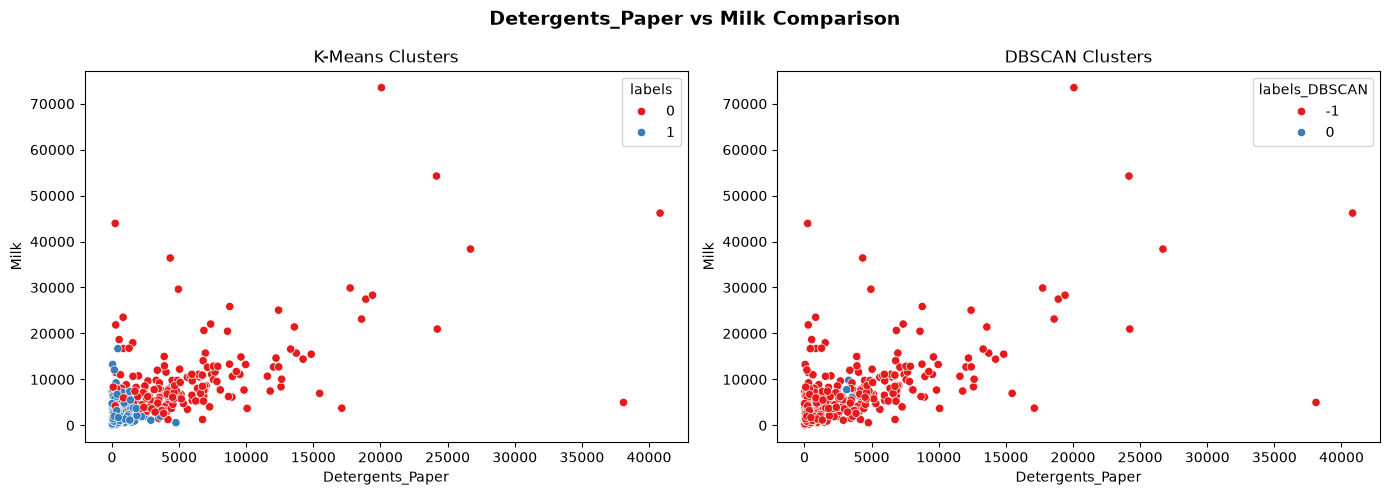

In [35]:
# Create a 1-row, 2-column side-by-side layout
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left Plot: K-Means
sns.scatterplot(data=wholesale_customer, x='Detergents_Paper', y='Milk', hue='labels', palette='Set1', ax=axes[0])
axes[0].set_title('K-Means Clusters')

# Right Plot: DBSCAN
sns.scatterplot(data=wholesale_customer, x='Detergents_Paper', y='Milk', hue='labels_DBSCAN', palette='Set1', ax=axes[1])
axes[1].set_title('DBSCAN Clusters')

plt.suptitle('Detergents_Paper vs Milk Comparison', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

Visualize `Grocery` as X and `Fresh` as y by `labels` and `labels_DBSCAN` respectively

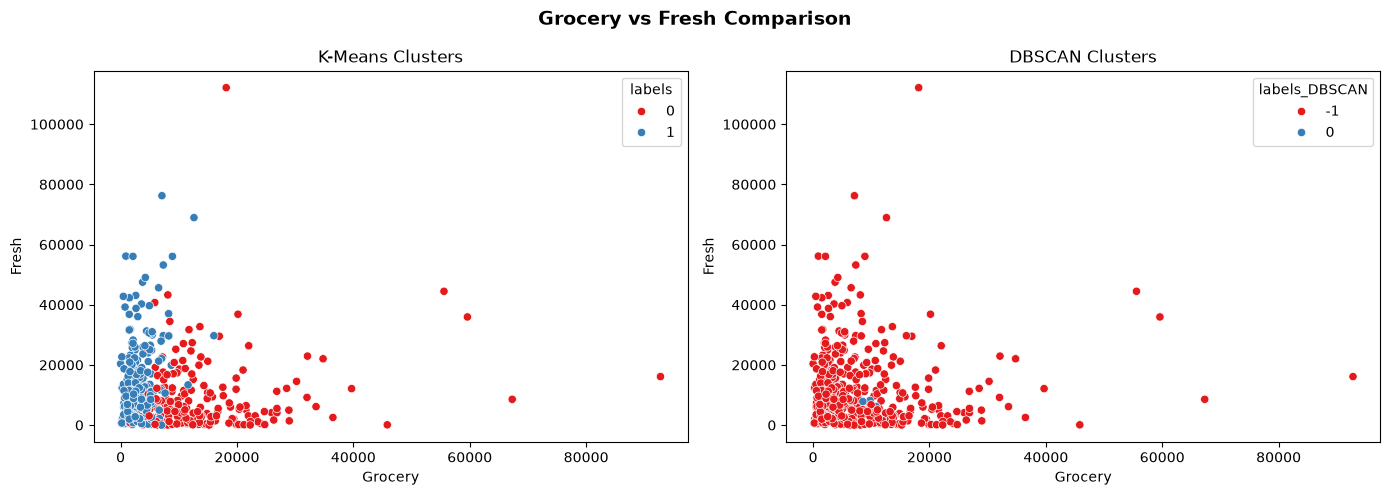

In [36]:
# Create a 1-row, 2-column side-by-side layout
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left Plot: K-Means
sns.scatterplot(data=wholesale_customer, x='Grocery', y='Fresh', hue='labels', palette='Set1', ax=axes[0])
axes[0].set_title('K-Means Clusters')

# Right Plot: DBSCAN
sns.scatterplot(data=wholesale_customer, x='Grocery', y='Fresh', hue='labels_DBSCAN', palette='Set1', ax=axes[1])
axes[1].set_title('DBSCAN Clusters')

plt.suptitle('Grocery vs Fresh Comparison', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


Visualize `Frozen` as X and `Delicassen` as y by `labels` and `labels_DBSCAN` respectively

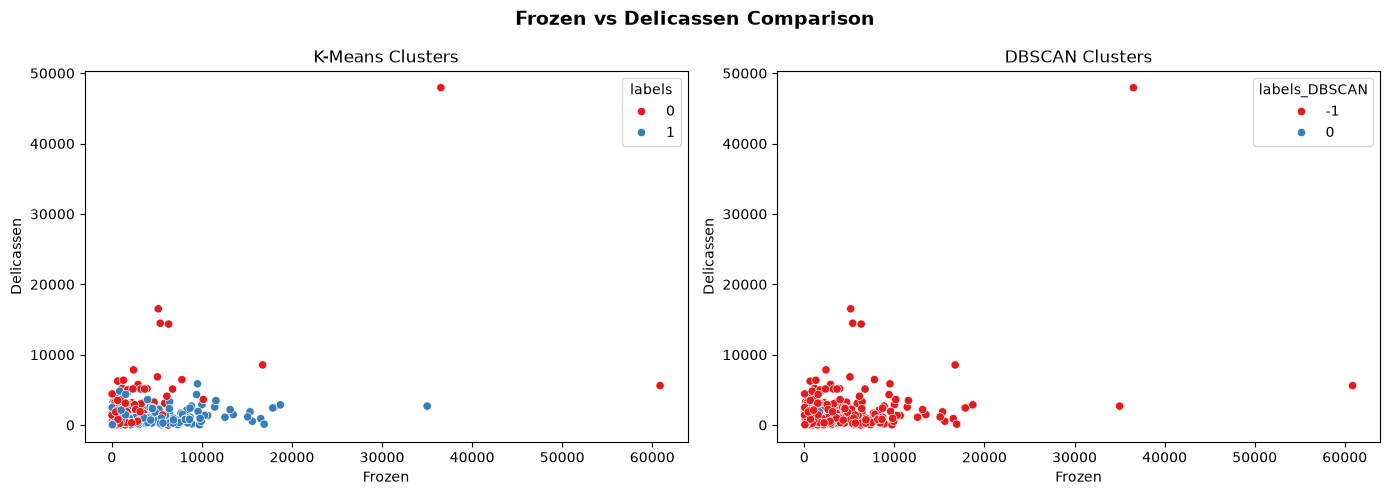

In [37]:
# Create a 1-row, 2-column side-by-side layout
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left Plot: K-Means
sns.scatterplot(data=wholesale_customer, x='Frozen', y='Delicassen', hue='labels', palette='Set1', ax=axes[0])
axes[0].set_title('K-Means Clusters')

# Right Plot: DBSCAN
sns.scatterplot(data=wholesale_customer, x='Frozen', y='Delicassen', hue='labels_DBSCAN', palette='Set1', ax=axes[1])
axes[1].set_title('DBSCAN Clusters')

plt.suptitle('Frozen vs Delicassen Comparison', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


Let's use a groupby to see how the mean differs between the groups. Group `customers` by `labels` and `labels_DBSCAN` respectively and compute the means for all columns.

In [39]:
# Group by K-Means labels and calculate the mean for each product category

kmeans_means = wholesale_customer.groupby('labels')[['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']].mean()
kmeans_means

# Group by DBSCAN labels and calculate the mean for each product category
dbscan_means = wholesale_customer.groupby('labels_DBSCAN')[['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']].mean()
dbscan_means


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
labels_DBSCAN,,,,,,
-1,12053.473563,5782.590805,7931.965517,3089.793103,2879.675862,1519.487356
0,7374.000000,6986.000000,9631.400000,1518.000000,3039.600000,1993.200000


Which algorithm appears to perform better?

**Your observations here**

- K-Means performs significantly better because it splits the customers into two logically distinct, useful business segments.
- K-Means Cluster 0 represents Retail/Supermarkets, showing massive average spending on Grocery, Milk, and Detergents_Paper.
- K-Means Cluster 1 represents Restaurants/Cafes, focusing their spending heavily on Fresh and Frozen goods.
- DBSCAN fails completely because it groups 99% of the customers into the noise category (-1), providing no actionable business insights.


# Bonus Challenge 2 - Changing K-Means Number of Clusters

As we mentioned earlier, we don't need to worry about the number of clusters with DBSCAN because it automatically decides that based on the parameters we send to it. But with K-Means, we have to supply the `n_clusters` param (if you don't supply `n_clusters`, the algorithm will use `8` by default). You need to know that the optimal number of clusters differs case by case based on the dataset. K-Means can perform badly if the wrong number of clusters is used.

In advanced machine learning, data scientists try different numbers of clusters and evaluate the results with statistical measures (read [here](https://en.wikipedia.org/wiki/Cluster_analysis#External_evaluation)). We are not using statistical measures today but we'll use our eyes instead. In the cells below, experiment with different number of clusters and visualize with scatter plots. What number of clusters seems to work best for K-Means?

c:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


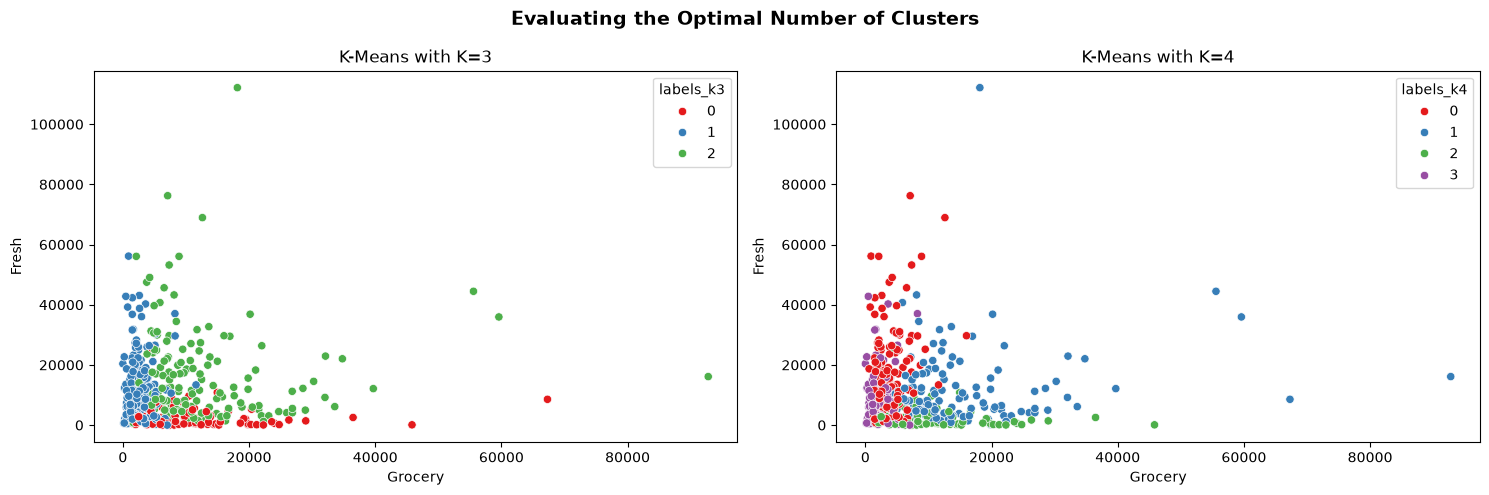

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# 1. Initialize two K-Means models with different numbers of clusters
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10).fit(customers_scale)
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10).fit(customers_scale)

# 2. Assign the new cluster configurations to temporary tracking columns
wholesale_customer['labels_k3'] = kmeans_3.labels_
wholesale_customer['labels_k4'] = kmeans_4.labels_

# 3. Build a side-by-side scatter plot comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 3-cluster structure
sns.scatterplot(data=wholesale_customer, x='Grocery', y='Fresh', hue='labels_k3', palette='Set1', ax=axes[0])
axes[0].set_title('K-Means with K=3')

# Plot 4-cluster structure
sns.scatterplot(data=wholesale_customer, x='Grocery', y='Fresh', hue='labels_k4', palette='Set1', ax=axes[1])
axes[1].set_title('K-Means with K=4')

plt.suptitle('Evaluating the Optimal Number of Clusters', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


**Your comment here**

- Using K=3 provides the best segmentation balance. 

# Bonus Challenge 3 - Changing DBSCAN `eps` and `min_samples`

Experiment changing the `eps` and `min_samples` params for DBSCAN. See how the results differ with scatter plot visualization.

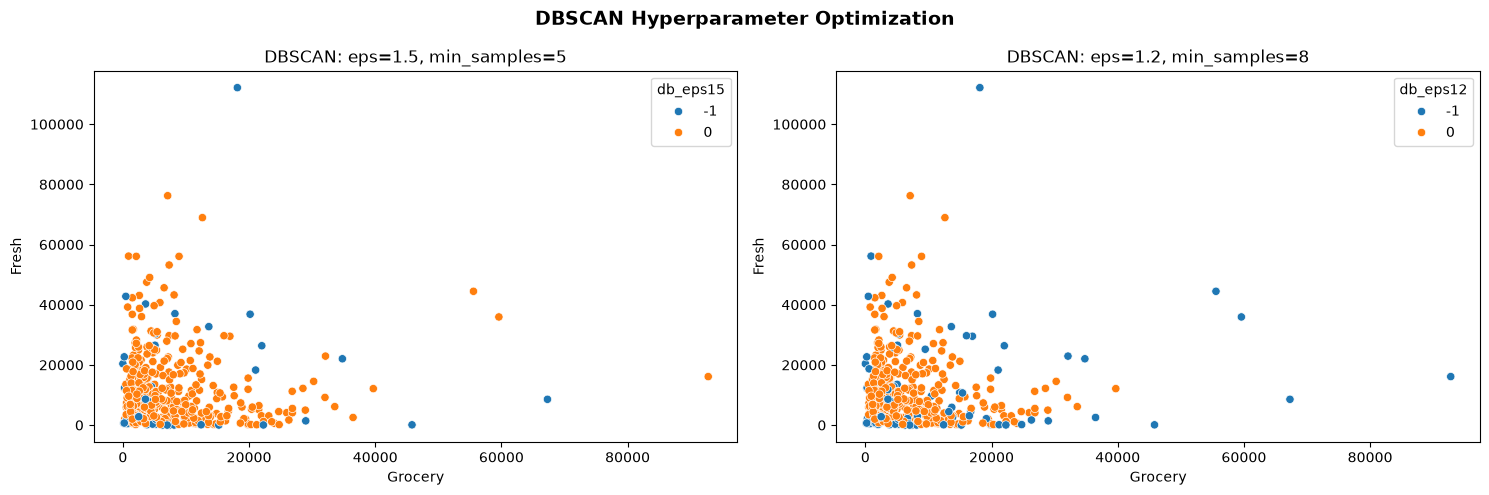

In [41]:
# 1. Train DBSCAN with adjusted parameters
dbscan_v1 = DBSCAN(eps=1.5, min_samples=5).fit(customers_scale)
dbscan_v2 = DBSCAN(eps=1.2, min_samples=8).fit(customers_scale)

# 2. Assign the results back to tracking columns
wholesale_customer['db_eps15'] = dbscan_v1.labels_
wholesale_customer['db_eps12'] = dbscan_v2.labels_

# 3. Create a side-by-side plot layout
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot performance of relaxed epsilon
sns.scatterplot(data=wholesale_customer, x='Grocery', y='Fresh', hue='db_eps15', palette='tab10', ax=axes[0])
axes[0].set_title('DBSCAN: eps=1.5, min_samples=5')

# Plot performance of alternative constraint setup
sns.scatterplot(data=wholesale_customer, x='Grocery', y='Fresh', hue='db_eps12', palette='tab10', ax=axes[1])
axes[1].set_title('DBSCAN: eps=1.2, min_samples=8')

plt.suptitle('DBSCAN Hyperparameter Optimization', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

**Your comment here**

- Increasing epsilon to 1.5 successfully resolves the noise issue.